# Website Classification Analysis

This notebook analyzes a dataset of website features to classify legitimate vs malicious websites.

## Import Required Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Load and Preprocess Data

In [10]:
# Load the dataset
df = pd.read_csv('Dataset.csv')

# Remove null values
df = df.dropna()

# Drop non-numeric columns that won't be used for modeling
columns_to_drop = ['FILENAME', 'URL', 'Domain', 'TLD']
df = df.drop(columns=columns_to_drop)

# Display basic information
print("Dataset Information:")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(df.columns)}")
print("\nFeature names:")
print(df.columns.tolist())

Dataset Information:
Number of samples: 235795
Number of features: 52

Feature names:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


## Feature Analysis and Visualization

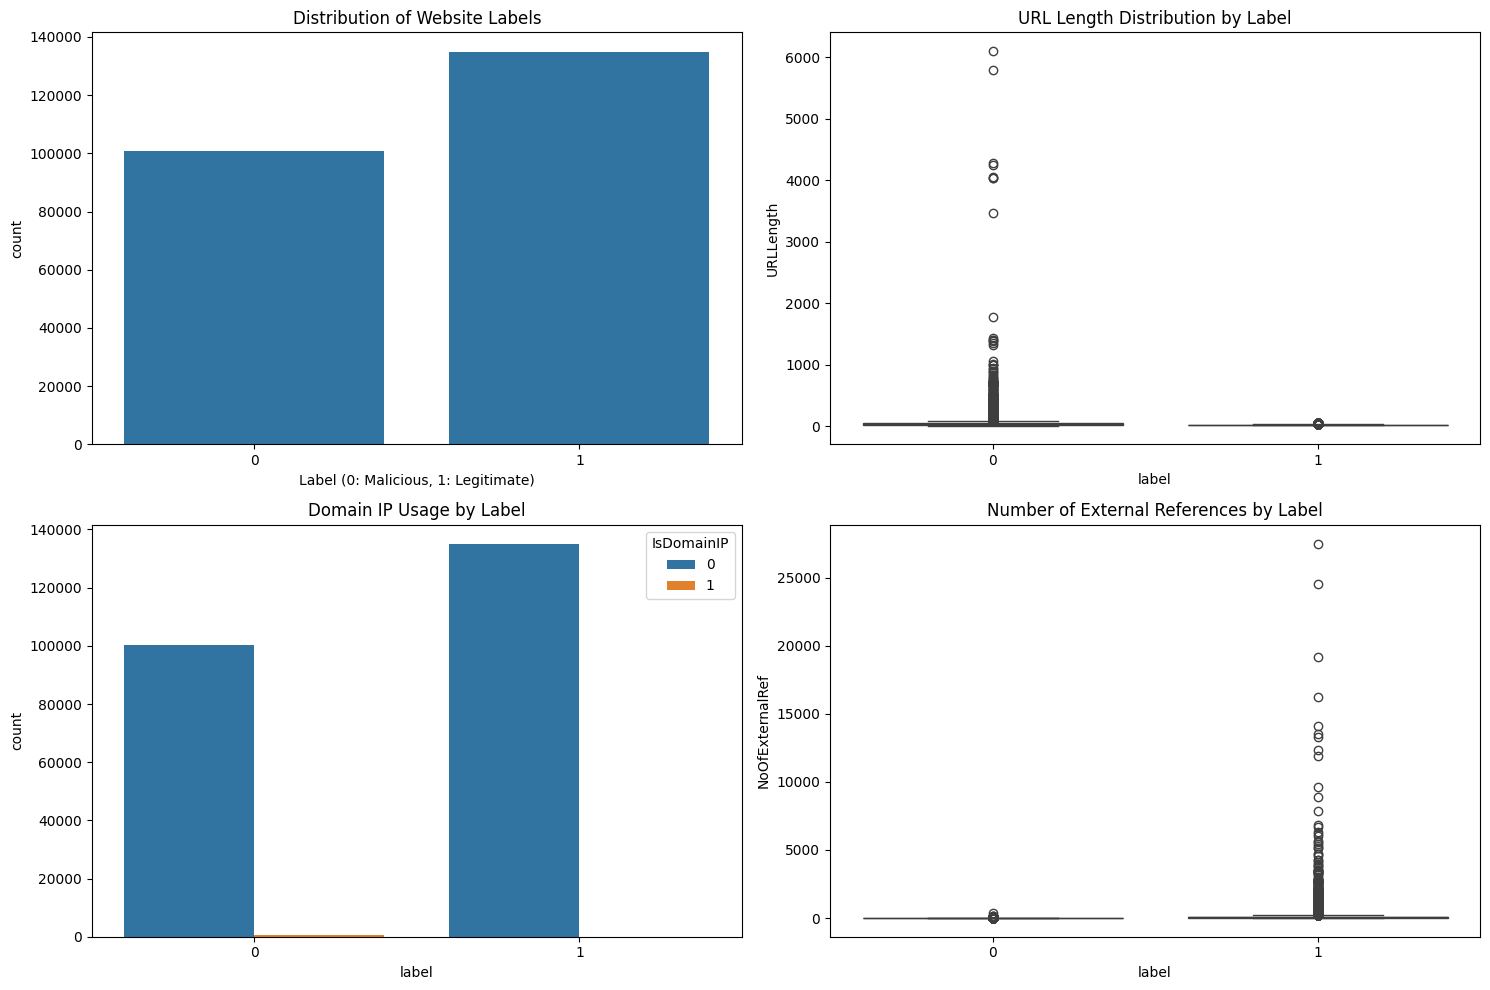

In [11]:
# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# Plot 1: Distribution of legitimate vs malicious websites
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='label')
plt.title('Distribution of Website Labels')
plt.xlabel('Label (0: Malicious, 1: Legitimate)')

# Plot 2: URL Length distribution by label
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='label', y='URLLength')
plt.title('URL Length Distribution by Label')

# Plot 3: Domain IP usage by label
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='label', hue='IsDomainIP')
plt.title('Domain IP Usage by Label')

# Plot 4: External References by label
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='label', y='NoOfExternalRef')
plt.title('Number of External References by Label')

plt.tight_layout()
plt.show()

## Model Training and Evaluation

In [12]:
# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Print model performance
print("Model Performance Report:")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: '3daviplataactivorepl'

## Feature Importance Analysis

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 10 most important features
print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features for Website Classification')
plt.show()